                                      ANALYSIS US NATURAL DISASTER: TRENDS & PATTERNS                                                            

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

1) DATA IMPORT

In [2]:
df = pd.read_csv("H:\Infosys Internship\database.csv")
df.head(5)

,Declaration Number,Declaration Type,Declaration Date,State,County,Disaster Type,Disaster Title,Start Date,End Date,Close Date,Individual Assistance Program,Individuals & Households Program,Public Assistance Program,Hazard Mitigation Program
0,DR-1,Disaster,05/02/1953,GA,NaN,Tornado,Tornado,05/02/1953,05/02/1953,06/01/1954,Yes,No,Yes,Yes
1,DR-2,Disaster,05/15/1953,TX,NaN,Tornado,Tornado and Heavy Rainfall,05/15/1953,05/15/1953,01/01/1958,Yes,No,Yes,Yes
2,DR-3,Disaster,05/29/1953,LA,NaN,Flood,Flood,05/29/1953,05/29/1953,02/01/1960,Yes,No,Yes,Yes
3,DR-4,Disaster,06/02/1953,MI,NaN,Tornado,Tornado,06/02/1953,06/02/1953,02/01/1956,Yes,No,Yes,Yes
4,DR-5,Disaster,06/06/1953,MT,NaN,Flood,Floods,06/06/1953,06/06/1953,12/01/1955,Yes,No,Yes,Yes


In [3]:
df.shape

(46185, 14)

In [4]:
df.dtypes  # checking Data Types

Declaration Number                  object
Declaration Type                    object
Declaration Date                    object
State                               object
County                              object
Disaster Type                       object
Disaster Title                      object
Start Date                          object
End Date                            object
Close Date                          object
Individual Assistance Program       object
Individuals & Households Program    object
Public Assistance Program           object
Hazard Mitigation Program           object
dtype: object

2) DATA CLEANING 

2.1DEALING WITH NULL VALUES

In [5]:
df.isnull().sum() # CHECKING NULL VALUES

Declaration Number                      0
Declaration Type                        0
Declaration Date                        0
State                                   0
County                                197
Disaster Type                           0
Disaster Title                          0
Start Date                              0
End Date                              342
Close Date                          10975
Individual Assistance Program           0
Individuals & Households Program        0
Public Assistance Program               0
Hazard Mitigation Program               0
dtype: int64

In [6]:
# Filling null values
df['County'] = df['County'].fillna(df['State']).fillna('Unknown')  # In Blank country value we fill with state column value for data consistency.

2.2: CHECKING FOR DOUBLICATE ROWS


In [7]:
df.duplicated().sum() # Hence this prove data does not have doublicate values

np.int64(0)

In [8]:
df.dtypes # HENCE We Conclude that all the data types are in String formate, we need to convert to right formate, date should be in date formate.


Declaration Number                  object
Declaration Type                    object
Declaration Date                    object
State                               object
County                              object
Disaster Type                       object
Disaster Title                      object
Start Date                          object
End Date                            object
Close Date                          object
Individual Assistance Program       object
Individuals & Households Program    object
Public Assistance Program           object
Hazard Mitigation Program           object
dtype: object

As of now we ignore other date and keep only starting date because end date and close date has null and our maximum insight will be on starting date onlym

In [9]:
df['Start Date'] = pd.to_datetime(df['Start Date'], errors='coerce')   # changing Data Type

In [10]:
df['Start Date Formatted'] = df['Start Date'].dt.strftime('%d-%m-%Y')  # change formate
df['Start Date Month'] = df['Start Date'].dt.month                     # create new column of month
df['Start Date Year'] = df['Start Date'].dt.year                       # create new column of year
df.head(6)

,Declaration Number,Declaration Type,Declaration Date,State,County,Disaster Type,Disaster Title,Start Date,End Date,Close Date,Individual Assistance Program,Individuals & Households Program,Public Assistance Program,Hazard Mitigation Program,Start Date Formatted,Start Date Month,Start Date Year
0,DR-1,Disaster,05/02/1953,GA,GA,Tornado,Tornado,1953-05-02,05/02/1953,06/01/1954,Yes,No,Yes,Yes,02-05-1953,5,1953
1,DR-2,Disaster,05/15/1953,TX,TX,Tornado,Tornado and Heavy Rainfall,1953-05-15,05/15/1953,01/01/1958,Yes,No,Yes,Yes,15-05-1953,5,1953
2,DR-3,Disaster,05/29/1953,LA,LA,Flood,Flood,1953-05-29,05/29/1953,02/01/1960,Yes,No,Yes,Yes,29-05-1953,5,1953
3,DR-4,Disaster,06/02/1953,MI,MI,Tornado,Tornado,1953-06-02,06/02/1953,02/01/1956,Yes,No,Yes,Yes,02-06-1953,6,1953
4,DR-5,Disaster,06/06/1953,MT,MT,Flood,Floods,1953-06-06,06/06/1953,12/01/1955,Yes,No,Yes,Yes,06-06-1953,6,1953
5,DR-6,Disaster,06/09/1953,MI,MI,Tornado,Tornado,1953-06-09,06/09/1953,03/30/1956,Yes,No,Yes,Yes,09-06-1953,6,1953


                                                                MILESTONE 1                                                                                     


                                                        INSIGHTS: PIVOT TABLE USING PANDAS                                                                           

1) NUMBER OF DISASTER PER YEAR TREND

In [11]:
most_affected_state =  pd.pivot_table(df, 
               values='Declaration Number', 
               index='Start Date Year', 
               aggfunc='count')

most_affected_state


,Declaration Number
Start Date Year,
1953,13
1954,17
1955,18
1956,16
1957,16
...,...
2013,738
2014,637
2015,1246


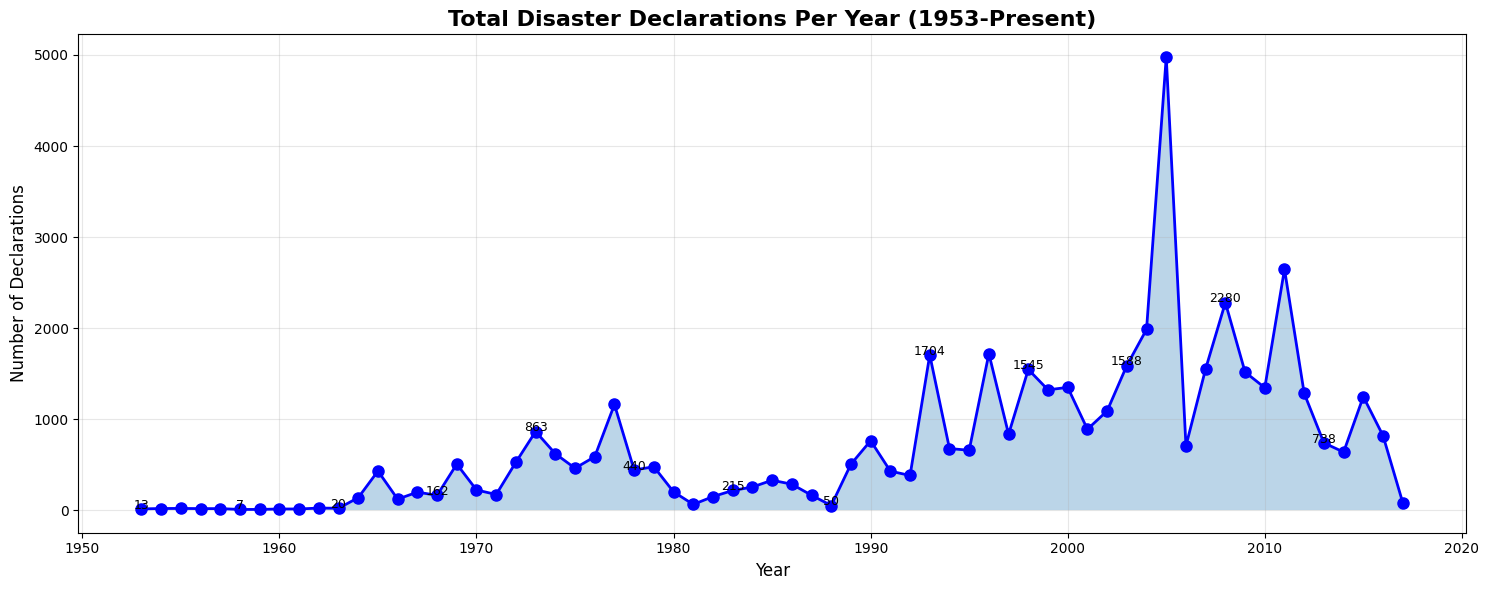

 Key Findings:
   Total declarations: 46185
   Earliest year: 1953
   Latest year: 2017
   Year with most declarations: 2005 (4978 declarations)


In [12]:
# Count declarations by year
yearly_counts = df['Start Date Year'].value_counts().sort_index()

plt.figure(figsize=(15, 6))
plt.plot(yearly_counts.index, yearly_counts.values, 
         marker='o', linewidth=2, markersize=8, color='blue')
plt.fill_between(yearly_counts.index, yearly_counts.values, alpha=0.3)

# Add labels and title
plt.title('Total Disaster Declarations Per Year (1953-Present)', fontsize=16, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Number of Declarations', fontsize=12)
plt.grid(True, alpha=0.3)

# Add value labels on some key points
for year, count in yearly_counts.iloc[::5].items():  # Label every 5th year
    plt.text(year, count+1, str(count), ha='center', fontsize=9)

plt.tight_layout()
plt.show()

print(f" Key Findings:")
print(f"   Total declarations: {len(df)}")
print(f"   Earliest year: {yearly_counts.index.min()}")
print(f"   Latest year: {yearly_counts.index.max()}")
print(f"   Year with most declarations: {yearly_counts.idxmax()} ({yearly_counts.max()} declarations)")

2) NUMBER Of DISASTER RECORDED

In [13]:
No_disaster_recorded =  pd.pivot_table(df, 
               values='Declaration Number', 
               index='Disaster Type', 
               aggfunc='count')

No_disaster_recorded

,Declaration Number
Disaster Type,
Chemical,18
Dam/Levee Break,6
Drought,1292
Earthquake,105
Fire,2647
Flood,9317
Human Cause,6
Hurricane,8764
Ice,1970


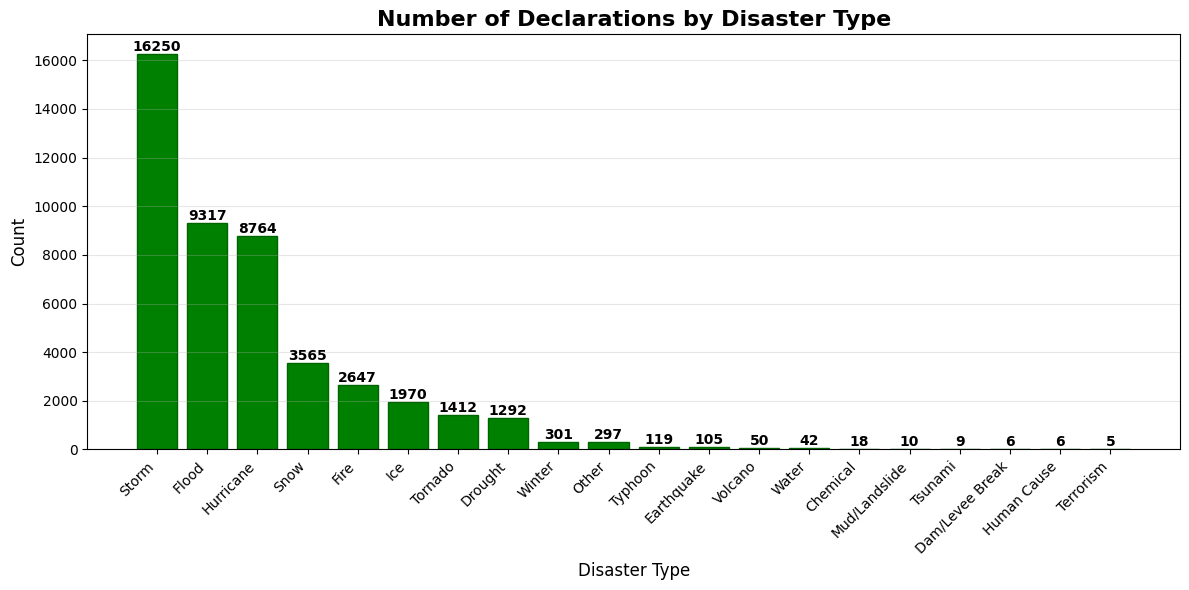

TOP DISASTER TYPES:
   1. Storm: 16250 declarations (35.2%)
   2. Flood: 9317 declarations (20.2%)
   3. Hurricane: 8764 declarations (19.0%)
   4. Snow: 3565 declarations (7.7%)
   5. Fire: 2647 declarations (5.7%)


In [14]:
# Count by disaster type
disaster_counts = df['Disaster Type'].value_counts()

plt.figure(figsize=(12, 6))
bars = plt.bar(range(len(disaster_counts)), disaster_counts.values, color='green', edgecolor='darkgreen')

# Add value labels
for i, (bar, count) in enumerate(zip(bars, disaster_counts.values)):
    plt.text(i, count+1, str(count), ha='center', va='bottom', fontweight='bold')

plt.title('Number of Declarations by Disaster Type', fontsize=16, fontweight='bold')
plt.xlabel('Disaster Type', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(range(len(disaster_counts)), disaster_counts.index, rotation=45, ha='right')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

print("TOP DISASTER TYPES:")
for i, (disaster, count) in enumerate(disaster_counts.head().items(), 1):
    percentage = (count/len(df))*100
    print(f"   {i}. {disaster}: {count} declarations ({percentage:.1f}%)")

3) TOP 20 STATES DISASTER RECORDED 

In [15]:
Country_Disaster = pd.pivot_table(df, 
               values='Declaration Number', 
               index='County', 
               aggfunc='count')

# Sort in descending order and take top 20
top_20_disasters = Country_Disaster.sort_values(by='Declaration Number', ascending=False).head(20)

# Display
top_20_disasters

,Declaration Number
County,
Washington County,409
Jefferson County,373
Jackson County,360
Franklin County,360
Lincoln County,320
Montgomery County,285
Clay County,280
Madison County,268
Monroe County,266


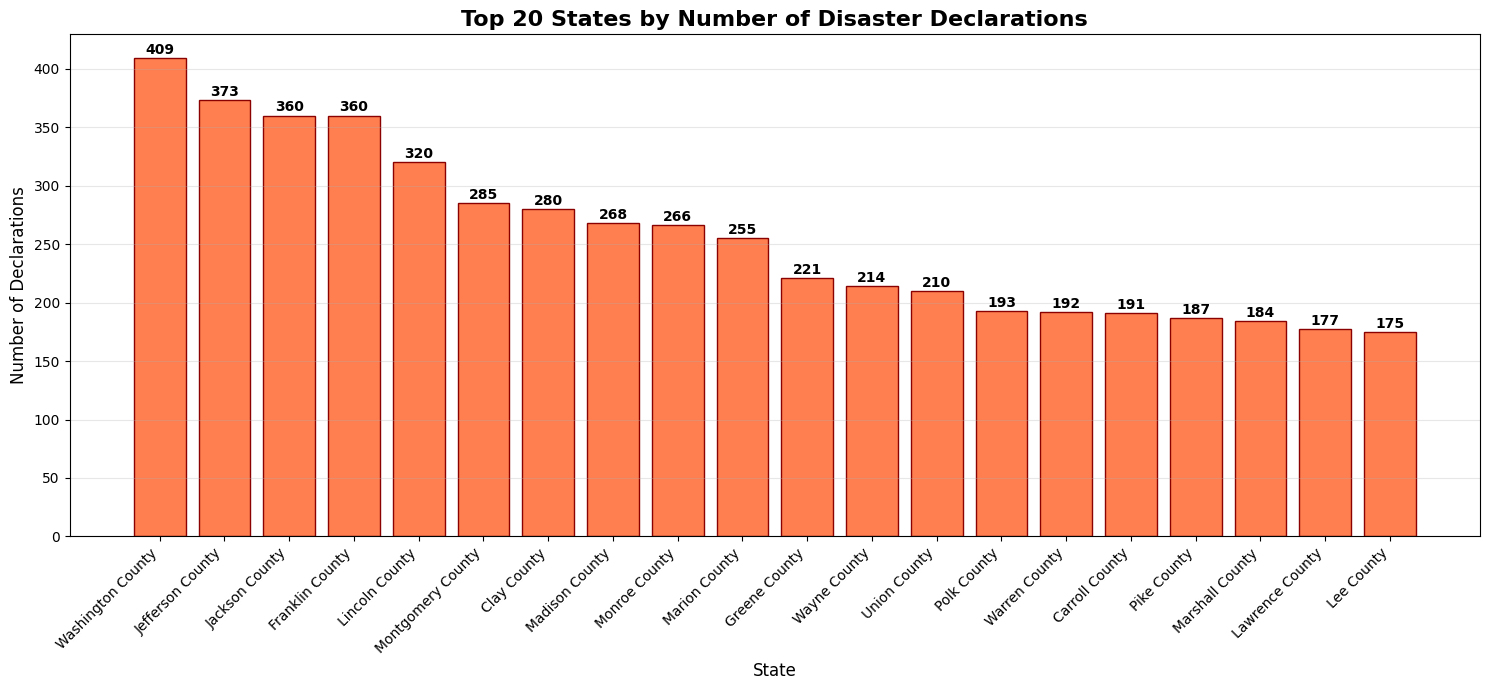

TOP 5 MOST AFFECTED STATES:
   1. Washington County: 409 declarations
   2. Jefferson County: 373 declarations
   3. Jackson County: 360 declarations
   4. Franklin County: 360 declarations
   5. Lincoln County: 320 declarations


In [16]:
# Count declarations by state
state_counts = df['County'].value_counts().head(20)  # Top 20 states

plt.figure(figsize=(15, 7))
bars = plt.bar(range(len(state_counts)), state_counts.values, color='coral', edgecolor='darkred')

# Add value labels on bars
for i, (bar, count) in enumerate(zip(bars, state_counts.values)):
    plt.text(i, count+1, str(count), ha='center', va='bottom', fontweight='bold')

plt.title('Top 20 States by Number of Disaster Declarations', fontsize=16, fontweight='bold')
plt.xlabel('State', fontsize=12)
plt.ylabel('Number of Declarations', fontsize=12)
plt.xticks(range(len(state_counts)), state_counts.index, rotation=45, ha='right')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

# Print top 5 states
print("TOP 5 MOST AFFECTED STATES:")
for i, (state, count) in enumerate(state_counts.head(5).items(), 1):
    print(f"   {i}. {state}: {count} declarations")

MILESTONE 2

In [17]:
# Set style for better looking plots
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

1) SEASONALITY PATTERN

In [18]:
# PIVOT TABLE 4: Monthly declarations
monthly_pivot = pd.pivot_table(
    df,
    values='Declaration Number',
    index='Start Date Month',
    aggfunc='count'
).reset_index()

# Rename column for clarity
monthly_pivot.rename(columns={'Start Date Month': 'Month', 'Declaration Number': 'Total_Declarations'}, inplace=True)

# Add month names
month_names = {1: 'Jan', 2: 'Feb', 3: 'Mar', 4: 'Apr', 5: 'May', 6: 'Jun',
               7: 'Jul', 8: 'Aug', 9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dec'}
monthly_pivot['Month Name'] = monthly_pivot['Month'].map(month_names)

# Sort by month number
monthly_pivot = monthly_pivot.sort_values('Month')

# Display
print("📊 MONTHLY DECLARATIONS PIVOT TABLE:")
print(monthly_pivot)
print("\n" + "-"*50)

📊 MONTHLY DECLARATIONS PIVOT TABLE:
    Month  Total_Declarations Month Name
0       1                4748        Jan
1       2                3244        Feb
2       3                4040        Mar
3       4                4584        Apr
4       5                4334        May
5       6                3941        Jun
6       7                2086        Jul
7       8                6452        Aug
8       9                5036        Sep
9      10                2492        Oct
10     11                1621        Nov
11     12                3607        Dec

--------------------------------------------------


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_3652\1997549529.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_3652\1997549529.py:24: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Lenovo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


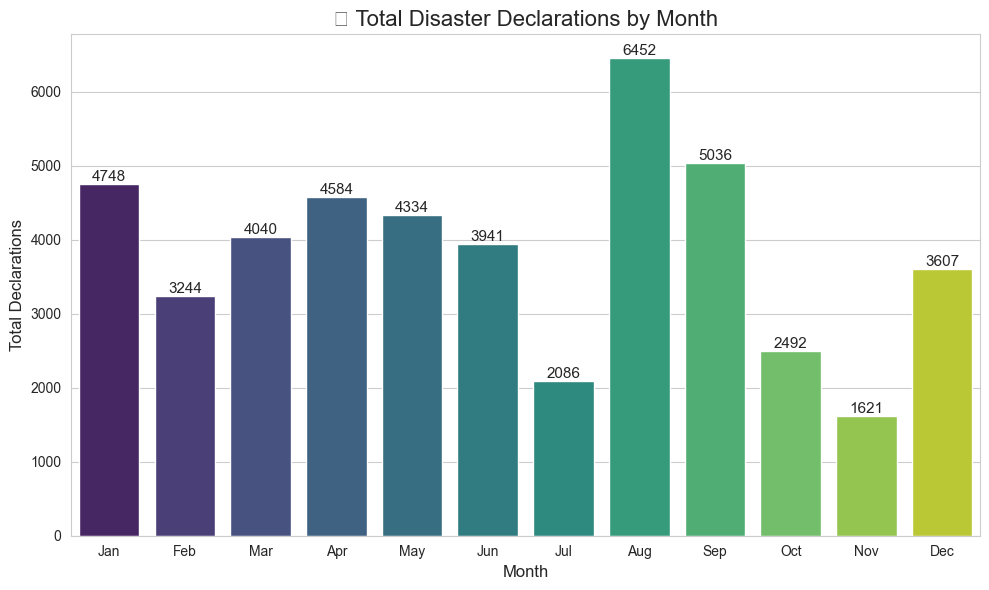

In [19]:
# Plot
plt.figure(figsize=(10,6))
barplot = sns.barplot(
    data=monthly_pivot, 
    x='Month Name', 
    y='Total_Declarations', 
    palette='viridis'
)

# Add data labels on top of each bar
for p in barplot.patches:
    height = p.get_height()
    barplot.annotate(
        f'{int(height)}', 
        (p.get_x() + p.get_width() / 2., height), 
        ha='center', va='bottom', 
        fontsize=11
    )

plt.title("📊 Total Disaster Declarations by Month", fontsize=16)
plt.xlabel("Month", fontsize=12)
plt.ylabel("Total Declarations", fontsize=12)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

2) YEAR OVER YEAR CHANGE ANALYSIS

In [20]:
yearly_pivot = pd.pivot_table(
    df, 
    values='Declaration Number',  # Count this column
    index='Start Date Year',                  # Rows = Year
    aggfunc='count'                # Count function
).reset_index()

# Rename columns for clarity
yearly_pivot.columns = ['Year', 'Total_Declarations']

# Sort by year
yearly_pivot = yearly_pivot.sort_values('Year')

print("yearly_pivot created successfully!")
print(yearly_pivot.head())
yearly_change_pivot = yearly_pivot.copy()
yearly_change_pivot['Change'] = yearly_change_pivot['Total_Declarations'].diff()
yearly_change_pivot['Change_Percent'] = (yearly_change_pivot['Total_Declarations'].pct_change() * 100).round(1)
yearly_change_pivot['Trend'] = yearly_change_pivot['Change'].apply(lambda x: 'Increase' if x > 0 else 'Decrease' if x < 0 else 'No Change')

print("YEARLY CHANGE PIVOT TABLE (Last 10 years):")
print(yearly_change_pivot.tail(10))
print("\n" + "-"*50)

yearly_pivot created successfully!
   Year  Total_Declarations
0  1953                  13
1  1954                  17
2  1955                  18
3  1956                  16
4  1957                  16
YEARLY CHANGE PIVOT TABLE (Last 10 years):
    Year  Total_Declarations  Change  Change_Percent     Trend
55  2008                2280   727.0            46.8  Increase
56  2009                1516  -764.0           -33.5  Decrease
57  2010                1344  -172.0           -11.3  Decrease
58  2011                2647  1303.0            96.9  Increase
59  2012                1282 -1365.0           -51.6  Decrease
60  2013                 738  -544.0           -42.4  Decrease
61  2014                 637  -101.0           -13.7  Decrease
62  2015                1246   609.0            95.6  Increase
63  2016                 817  -429.0           -34.4  Decrease
64  2017                  82  -735.0           -90.0  Decrease

--------------------------------------------------


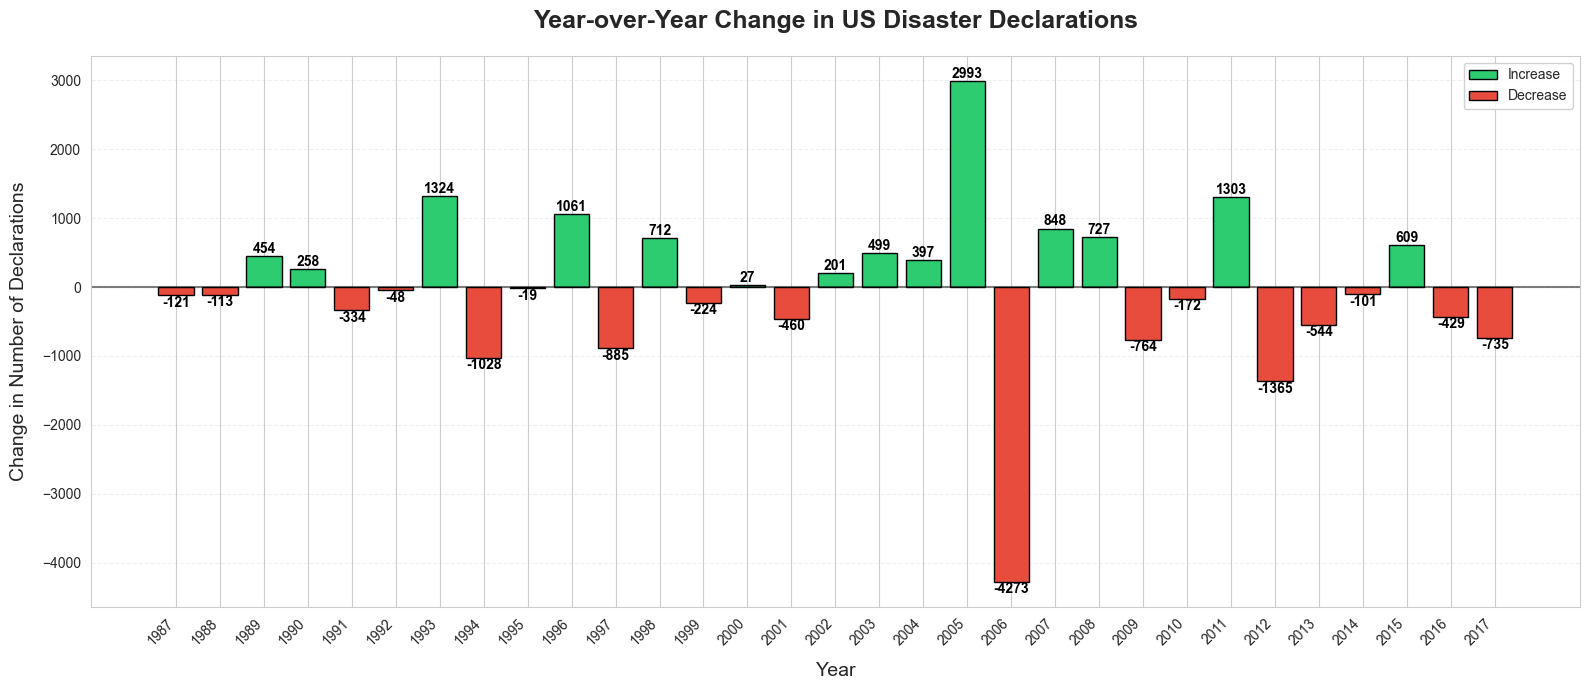


KEY INSIGHTS:
   • Total years analyzed: 31
   • Years with increase: 14
   • Years with decrease: 17
   • Best year: 2005 (+2993)
   • Worst year: 2006 (-4273)


In [21]:
# VISUALIZATION: Simple and Clean Year-over-Year
plt.figure(figsize=(16, 7))

# Filter last 30 years for better visibility (optional)
recent_data = yearly_change_pivot[yearly_change_pivot['Year'] >= yearly_change_pivot['Year'].max() - 30]

# Create bars
bars = plt.bar(range(len(recent_data)), recent_data['Change'], 
               color=['#2ecc71' if x > 0 else '#e74c3c' for x in recent_data['Change']],
               edgecolor='black', linewidth=1)

# Add zero line
plt.axhline(y=0, color='black', linestyle='-', linewidth=1.5, alpha=0.5)

# Customize
plt.title('Year-over-Year Change in US Disaster Declarations', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Year', fontsize=14, labelpad=10)
plt.ylabel('Change in Number of Declarations', fontsize=14, labelpad=10)
plt.xticks(range(len(recent_data)), recent_data['Year'].astype(str), rotation=45, ha='right')

# Add value labels
for i, (bar, change) in enumerate(zip(bars, recent_data['Change'])):
    height = bar.get_height()
    if abs(change) > 10:  # Only label significant changes
        plt.text(bar.get_x() + bar.get_width()/2., 
                height + (2 if height > 0 else -8),
                f'{int(change)}', 
                ha='center', 
                va='bottom' if height > 0 else 'top',
                fontweight='bold',
                fontsize=10,
                color='black')

# Add grid
plt.grid(True, alpha=0.3, axis='y', linestyle='--')

# Add legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#2ecc71', edgecolor='black', label='Increase'),
                   Patch(facecolor='#e74c3c', edgecolor='black', label='Decrease')]
plt.legend(handles=legend_elements, loc='upper right', framealpha=0.9)

plt.tight_layout()
plt.show()

# Print summary
print("\nKEY INSIGHTS:")
print(f"   • Total years analyzed: {len(recent_data)}")
print(f"   • Years with increase: {(recent_data['Change'] > 0).sum()}")
print(f"   • Years with decrease: {(recent_data['Change'] < 0).sum()}")
print(f"   • Best year: {recent_data.loc[recent_data['Change'].idxmax(), 'Year']} (+{recent_data['Change'].max():.0f})")
print(f"   • Worst year: {recent_data.loc[recent_data['Change'].idxmin(), 'Year']} ({recent_data['Change'].min():.0f})")

3) TOP 5 MOST EFFECTED STATE WISE TREND OVER TIME

In [22]:
# Find top 5 most affected states
top_states = df['State'].value_counts().head().index.tolist()
print(f" Top 5 States: {top_states}")

# PIVOT TABLE 8: Top states by year
state_year_pivot = pd.pivot_table(
    df[df['State'].isin(top_states)],
    values='Declaration Number',
    index='Start Date Year',
    columns='State',
    aggfunc='count',
    fill_value=0
).reset_index()

print("\n STATE-YEAR PIVOT TABLE (First 10 rows):")
print(state_year_pivot.head(10))
print("\n" + "-"*50)

 Top 5 States: ['TX', 'MO', 'KY', 'VA', 'OK']

 STATE-YEAR PIVOT TABLE (First 10 rows):
State  Start Date Year  KY  MO  OK  TX  VA
0                 1953   0   0   0   2   0
1                 1954   0   0   0   1   0
2                 1955   0   0   1   0   0
3                 1956   0   0   1   0   0
4                 1957   1   1   1   1   1
5                 1958   0   0   0   1   0
6                 1959   0   0   2   1   0
7                 1960   0   1   1   1   0
8                 1961   0   1   0   1   0
9                 1962   1   0   0   0   1

--------------------------------------------------


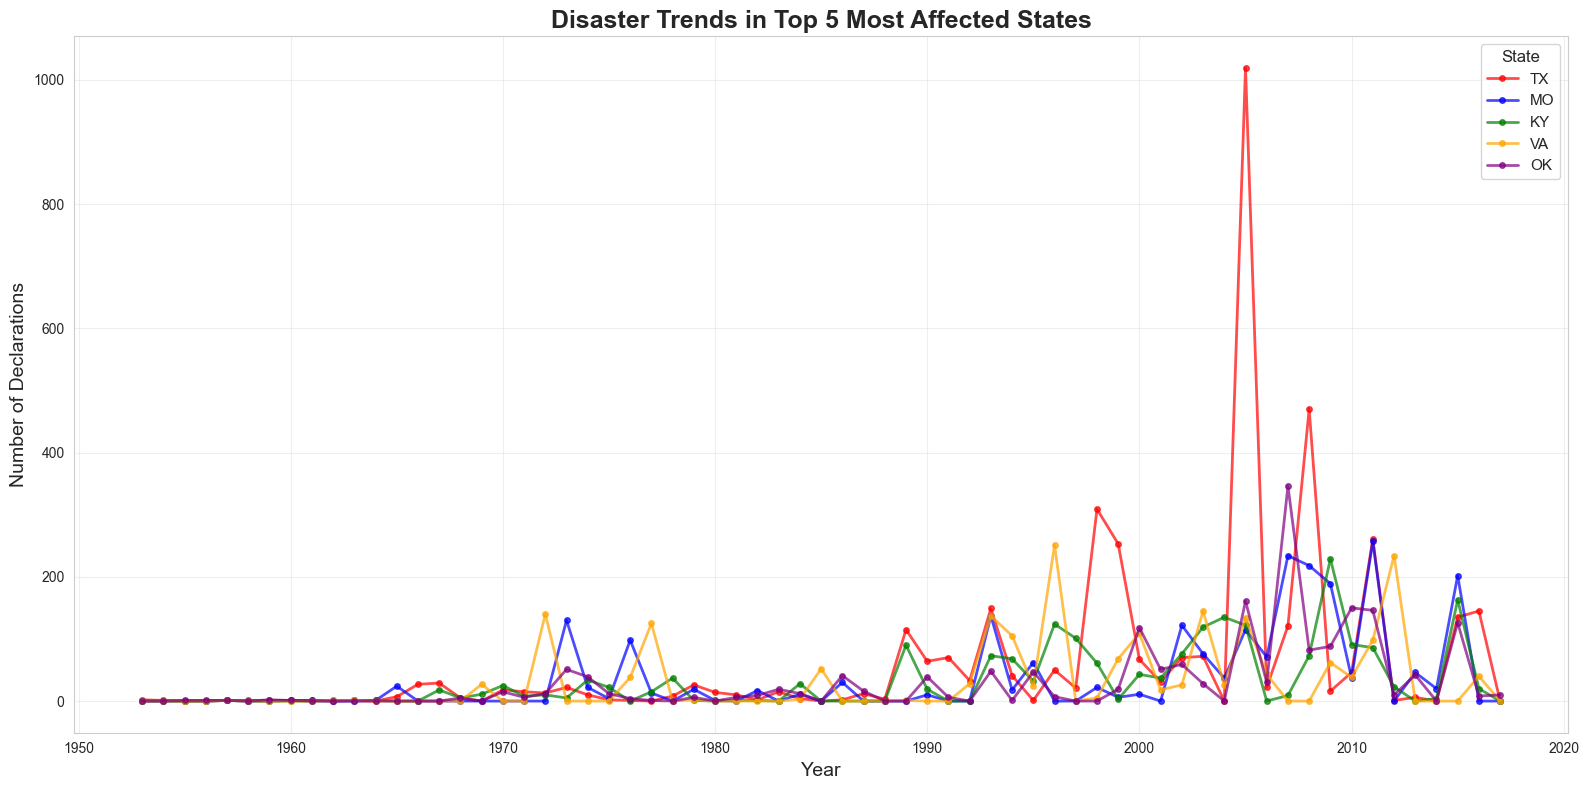

In [23]:
plt.figure(figsize=(16, 8))

# Plot each state
colors = ['red', 'blue', 'green', 'orange', 'purple']
for i, state in enumerate(top_states):
    if state in state_year_pivot.columns:
        plt.plot(state_year_pivot['Start Date Year'], state_year_pivot[state],
                marker='o', linewidth=2, markersize=4,
                color=colors[i], label=state, alpha=0.7)

plt.title('Disaster Trends in Top 5 Most Affected States', fontsize=18, fontweight='bold')
plt.xlabel('Year', fontsize=14)
plt.ylabel('Number of Declarations', fontsize=14)
plt.legend(title='State', fontsize=11, title_fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [24]:
# Exporting Clean Data in CSV format
df.to_csv("H:/Infosys Internship/cleaned_data.csv", index=False)

MILESTONE 3: Geographical Pattern Visualization